## 💎 Diamond Dynamics: Price Prediction and Market Segmentation


##  1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import boxcox

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Feature Selection
from sklearn.feature_selection import RFE

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Model Saving
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


##  2. Load Dataset

In [2]:
# Load diamonds dataset (seaborn built-in = same 53940 rows, 10 features)
df = sns.load_dataset('diamonds')
print(f'Shape: {df.shape}')
df.head()

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print('Dataset Info:')
df.info()
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

Basic Statistics:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


##  3. Data Preprocessing

In [4]:
# 3.1 Check missing values
print('Missing Values:')
print(df.isnull().sum())

# 3.2 Convert zero values in x, y, z to NaN
print(f'\nZero values — x:{(df.x==0).sum()}, y:{(df.y==0).sum()}, z:{(df.z==0).sum()}')
df['x'] = df['x'].replace(0, np.nan)
df['y'] = df['y'].replace(0, np.nan)
df['z'] = df['z'].replace(0, np.nan)

# Impute with median
for col in ['x', 'y', 'z']:
    df[col].fillna(df[col].median(), inplace=True)

print('\nAfter imputation - missing values:')
print(df.isnull().sum())

Missing Values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Zero values — x:8, y:7, z:20

After imputation - missing values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [5]:
# 3.3 Remove physically impossible outliers (y > 20mm, z > 20mm)
df = df[(df['y'] < 20) & (df['z'] < 20)]
print(f'Shape after removing impossible values: {df.shape}')

Shape after removing impossible values: (53937, 10)


##  4. Exploratory Data Analysis (EDA)

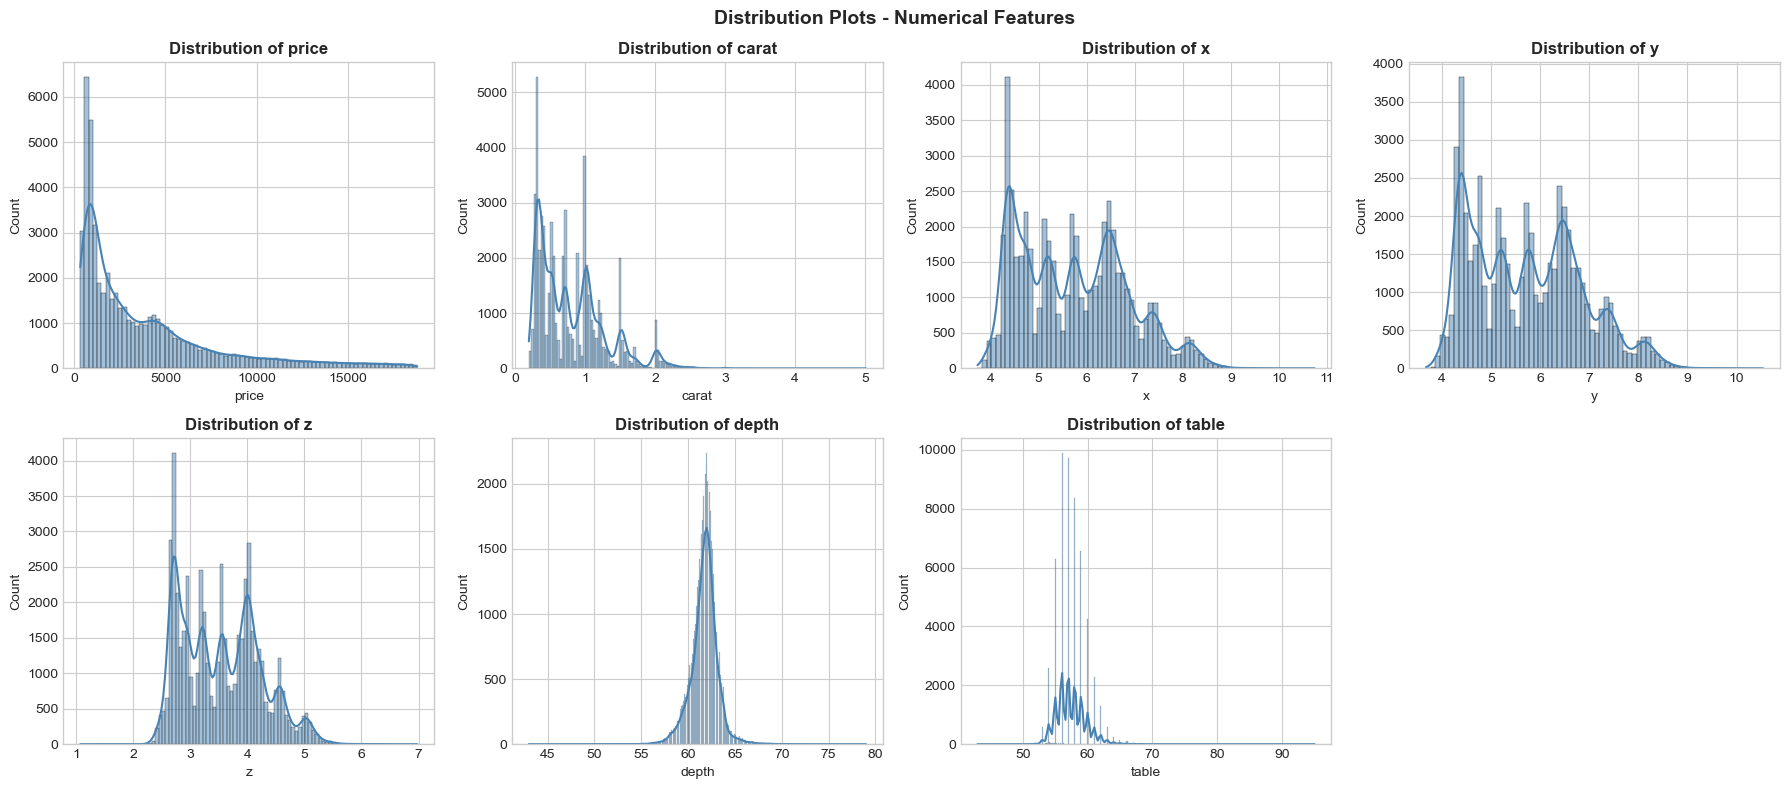

In [6]:
# 4.1 Distribution plots for numerical features
num_cols = ['price', 'carat', 'x', 'y', 'z', 'depth', 'table']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
axes[-1].set_visible(False)
plt.suptitle('Distribution Plots - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

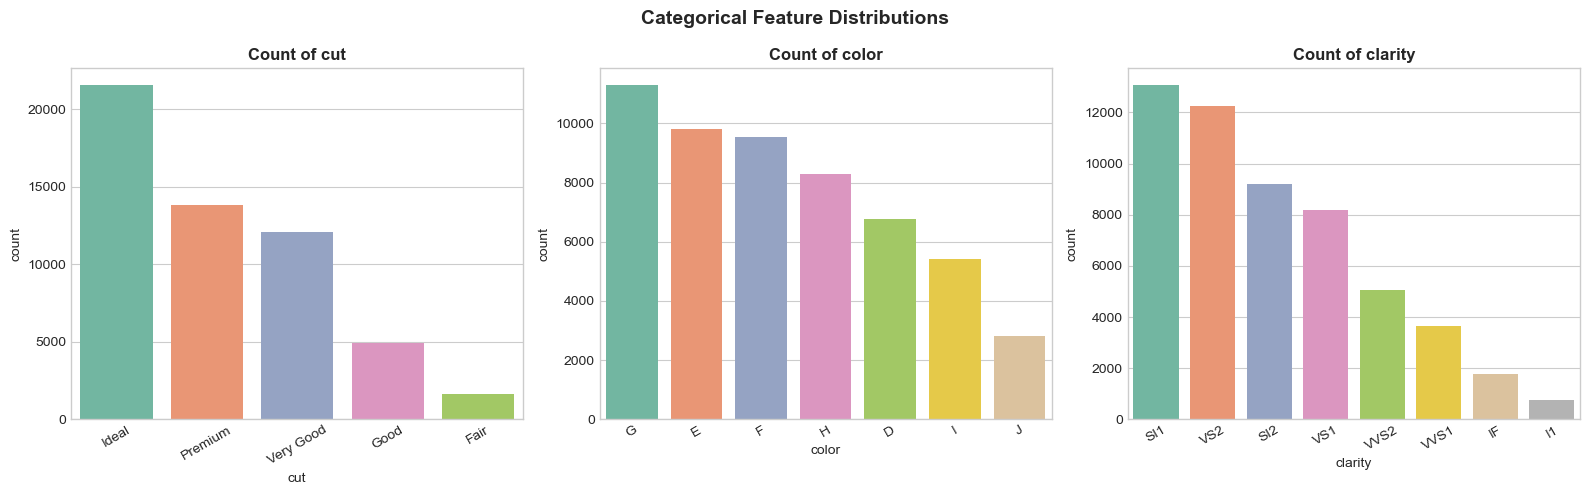

In [7]:
# 4.2 Count plots for categorical features
cat_cols = ['cut', 'color', 'clarity']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2', order=order)
    axes[i].set_title(f'Count of {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

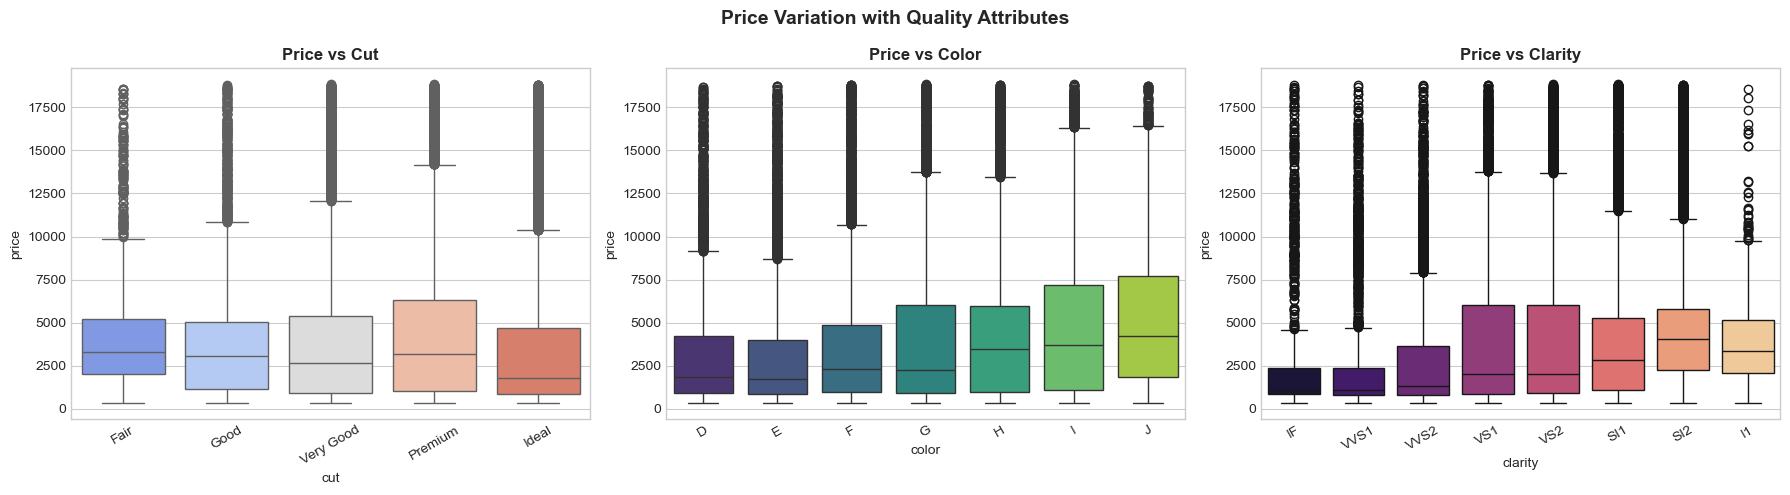

In [8]:
# 4.3 Price variation with categorical features (boxplots)
cut_order    = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order  = ['D','E','F','G','H','I','J']
clarity_order= ['IF','VVS1','VVS2','VS1','VS2','SI1','SI2','I1']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='cut',     y='price', order=cut_order,     ax=axes[0], palette='coolwarm')
sns.boxplot(data=df, x='color',   y='price', order=color_order,   ax=axes[1], palette='viridis')
sns.boxplot(data=df, x='clarity', y='price', order=clarity_order, ax=axes[2], palette='magma')
for ax, title in zip(axes, ['Price vs Cut', 'Price vs Color', 'Price vs Clarity']):
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Price Variation with Quality Attributes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_price_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

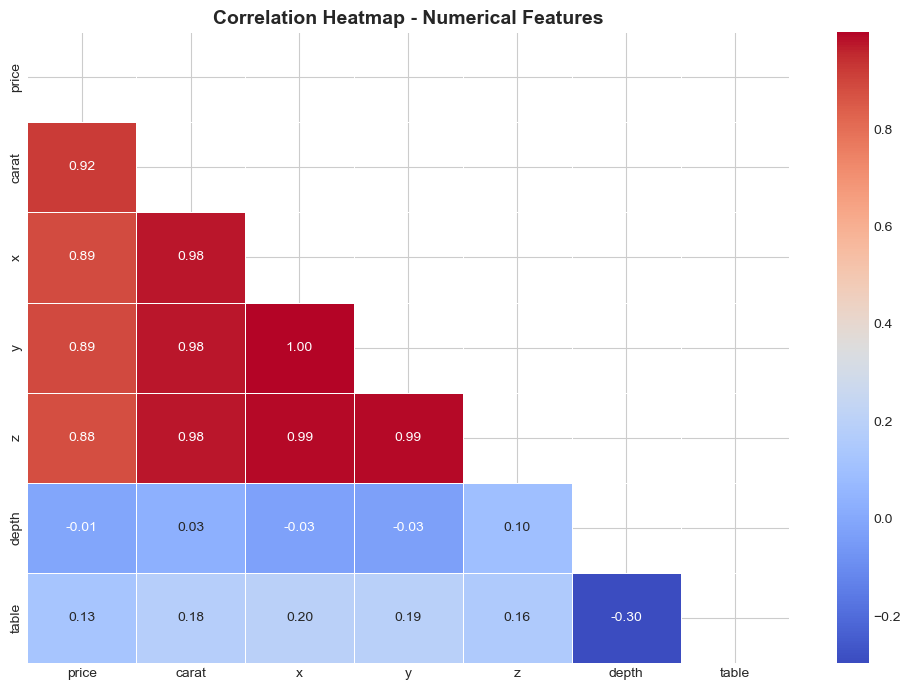

In [9]:
# 4.4 Correlation Heatmap
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

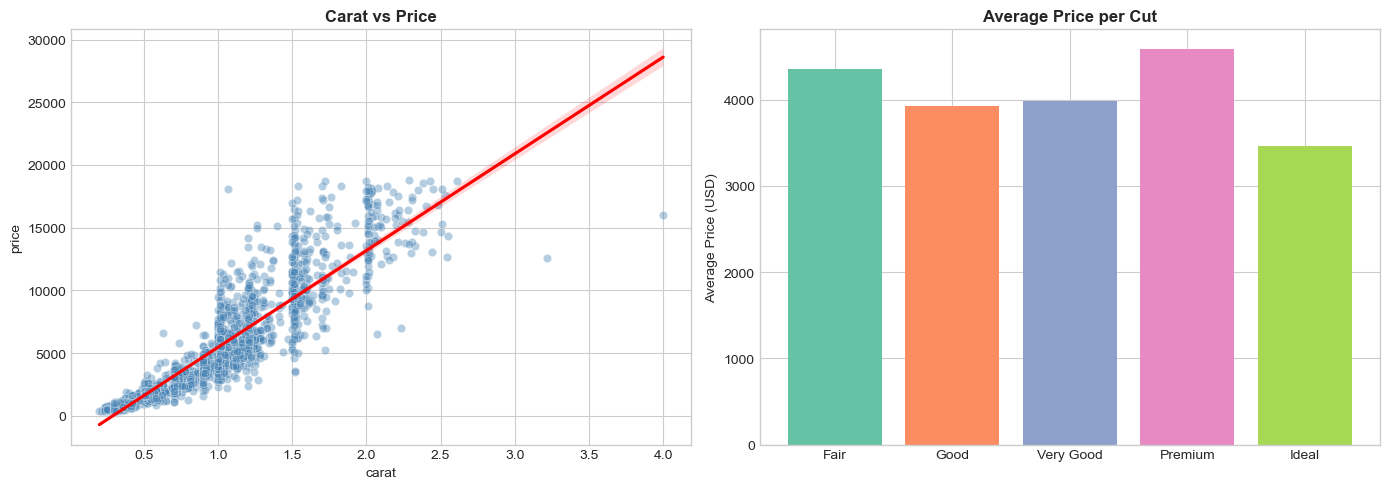

In [10]:
# 4.5 Carat vs Price regression lineplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(3000, random_state=42), x='carat', y='price',
                alpha=0.4, color='steelblue', ax=axes[0])
sns.regplot(data=df.sample(3000, random_state=42), x='carat', y='price',
            scatter=False, color='red', ax=axes[0])
axes[0].set_title('Carat vs Price', fontweight='bold')

# Average price per cut
avg_price = df.groupby('cut')['price'].mean().reindex(cut_order)
axes[1].bar(avg_price.index, avg_price.values, color=sns.color_palette('Set2', 5))
axes[1].set_title('Average Price per Cut', fontweight='bold')
axes[1].set_ylabel('Average Price (USD)')
plt.tight_layout()
plt.savefig('eda_carat_price.png', dpi=150, bbox_inches='tight')
plt.show()

##  5. Outlier Handling

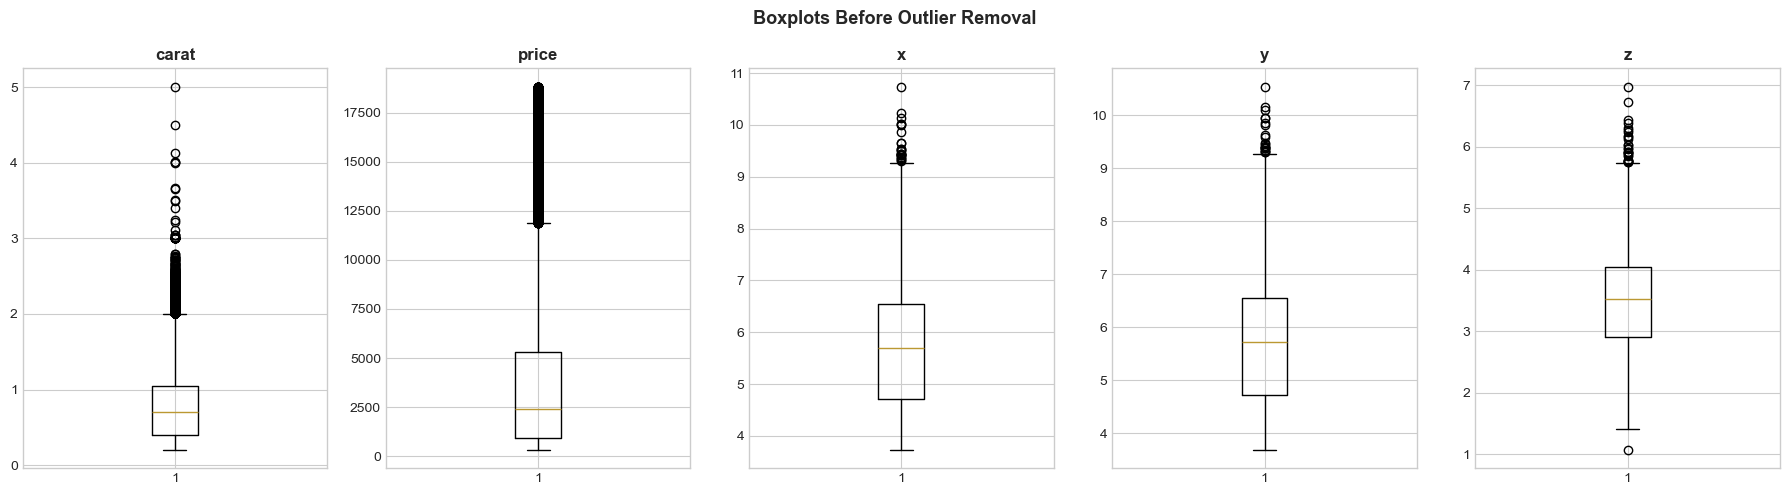

carat: removed 1889 outliers
price: removed 2534 outliers
x: removed 0 outliers
y: removed 0 outliers
z: removed 1 outliers

Shape after outlier removal: (49513, 10)


In [11]:
# Boxplots to visualize outliers before removal
outlier_cols = ['carat', 'price', 'x', 'y', 'z']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Boxplots Before Outlier Removal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR Method
def remove_outliers_iqr(data, cols):
    df_clean = data.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        print(f'{col}: removed {before - len(df_clean)} outliers')
    return df_clean

df = remove_outliers_iqr(df, outlier_cols)
print(f'\nShape after outlier removal: {df.shape}')

##  6. Skewness Handling

In [12]:
# Check skewness
skew_cols = ['price', 'carat', 'x', 'y', 'z']
print('Skewness before transformation:')
for col in skew_cols:
    print(f'  {col}: {df[col].skew():.4f}')

# Apply log transformation on highly skewed (|skew| > 1)
for col in skew_cols:
    if abs(df[col].skew()) > 1:
        df[f'{col}_log'] = np.log1p(df[col])
        print(f'  ✅ Applied log1p to {col} → skew: {df[f"{col}_log"].skew():.4f}')

Skewness before transformation:
  price: 1.1262
  carat: 0.6588
  x: 0.2190
  y: 0.2134
  z: 0.2200
  ✅ Applied log1p to price → skew: 0.0304


##  7. Feature Engineering

In [13]:
USD_TO_INR = 83.5  # Fixed conversion rate

# Convert price to INR
df['price_inr'] = df['price'] * USD_TO_INR

# Derived features
df['volume']          = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])
df['carat_category']  = pd.cut(df['carat'],
                                bins=[0, 0.5, 1.5, np.inf],
                                labels=['Light', 'Medium', 'Heavy'])

print('New features added:')
print(df[['price_inr','volume','price_per_carat','dimension_ratio','carat_category']].head())

New features added:
   price_inr     volume  price_per_carat  dimension_ratio carat_category
0    27221.0  38.202030      1417.391304         1.631687          Light
1    27221.0  34.505856      1552.380952         1.673160          Light
2    27304.5  38.076885      1421.739130         1.757576          Light
3    27889.0  46.724580      1151.724138         1.602662          Light
4    27972.5  51.917250      1080.645161         1.580000          Light


##  8. Encoding Categorical Variables

In [15]:
df_encoded = df.copy()

# Ordinal encoding for ordered categoricals
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']   # D is best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
cc_order      = ['Light', 'Medium', 'Heavy']

oe = OrdinalEncoder(categories=[cut_order, color_order, clarity_order, cc_order])
df_encoded[['cut','color','clarity','carat_category']] = oe.fit_transform(
    df_encoded[['cut','color','clarity','carat_category']]
)

# Save the encoder for Streamlit
with open('ordinal_encoder.pkl', 'wb') as f:
    pickle.dump(oe, f)

print('✅ Encoding done!')
df_encoded.head(3)

✅ Encoding done!


,carat,cut,color,clarity,depth,table,price,x,y,z,price_log,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43,5.789960,27221.0,38.202030,1417.391304,1.631687,0.0
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31,5.789960,27221.0,34.505856,1552.380952,1.673160,0.0
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31,5.793014,27304.5,38.076885,1421.739130,1.757576,0.0


##  9. Feature Selection (Correlation + VIF)

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select final feature set for regression (drop log-transformed cols, keep originals)
feature_cols = ['carat', 'cut', 'color', 'clarity', 'depth', 'table',
                'x', 'y', 'z', 'volume', 'price_per_carat',
                'dimension_ratio', 'carat_category']

# Drop price, price_inr, log cols from feature set
drop_cols = [c for c in df_encoded.columns if 'price' in c or '_log' in c]
X_all = df_encoded.drop(columns=drop_cols + ['carat_category'])
# Keep only numeric features
X_all = X_all.select_dtypes(include=[np.number])
target_usd = df_encoded['price']
target_inr = df_encoded['price_inr']

print('Features used for model:', list(X_all.columns))

# VIF check
vif_data = pd.DataFrame()
vif_data['Feature'] = X_all.columns
vif_data['VIF']     = [variance_inflation_factor(X_all.values, i)
                        for i in range(X_all.shape[1])]
print('\nVIF Values:')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

Features used for model: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'volume', 'dimension_ratio']

VIF Values:
        Feature          VIF
              z 44806.680862
              y 22750.950841
              x 21164.841995
dimension_ratio 12503.193066
          depth 12046.021605
         volume  2616.397925
          carat  2300.420338
          table   949.984612
            cut    11.247956
          color     5.831099
        clarity     5.691707


In [17]:
# Drop highly correlated features (VIF > 10 typically indicates multicollinearity)
# x, y, z and volume are highly correlated; keep volume and carat, drop x/y/z
features_final = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'volume', 'dimension_ratio']
X = df_encoded[features_final]
y_usd = target_usd
y_inr = target_inr

print('Final feature set:', features_final)

Final feature set: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'volume', 'dimension_ratio']


##  10. Regression — Price Prediction

In [18]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_inr, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (39610, 8), Test size: (9903, 8)


In [19]:
# Evaluation helper
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae,2), 'MSE': round(mse,2),
            'RMSE': round(rmse,2), 'R2': round(r2,4)}

results = []

# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
results.append(evaluate_model('Linear Regression', y_test, lr.predict(X_test_sc)))

# --- Model 2: Decision Tree ---
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
results.append(evaluate_model('Decision Tree', y_test, dt.predict(X_test)))

# --- Model 3: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model('Random Forest', y_test, rf.predict(X_test)))

# --- Model 4: XGBoost ---
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                   random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
results.append(evaluate_model('XGBoost', y_test, xgb.predict(X_test)))

# --- Model 5: KNN ---
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_sc, y_train)
results.append(evaluate_model('KNN', y_test, knn.predict(X_test_sc)))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model      MAE          MSE     RMSE     R2
Linear Regression 46380.65 4.044754e+09 63598.38 0.9131
    Decision Tree 20291.58 1.131796e+09 33642.18 0.9757
    Random Forest 16936.72 8.209801e+08 28652.75 0.9824
          XGBoost 16546.26 7.738076e+08 27817.40 0.9834
              KNN 24159.70 1.557346e+09 39463.22 0.9666


In [20]:
# --- Model 6: ANN (TensorFlow/Keras) ---
tf.random.set_seed(42)

ann = keras.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

ann.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                            restore_best_weights=True)
history = ann.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

ann_preds = ann.predict(X_test_sc).flatten()
results.append(evaluate_model('ANN (Keras)', y_test, ann_preds))
results_df = pd.DataFrame(results)
print('\nAll Model Results:')
print(results_df.sort_values('R2', ascending=False).to_string(index=False))

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 110680317952.0000 - mae: 252849.2344 - val_loss: 109049978880.0000 - val_mae: 250293.0469
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 110562492416.0000 - mae: 252740.2344 - val_loss: 108837888000.0000 - val_mae: 250098.8594
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 110216331264.0000 - mae: 252415.0000 - val_loss: 108219949056.0000 - val_mae: 249497.5781
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 109468958720.0000 - mae: 251683.4062 - val_loss: 106969055232.0000 - val_mae: 248248.1406
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 108126871552.0000 - mae: 250343.7656 - val_loss: 105047531520.0000 - val_mae: 246297.5000
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 106050199552.0000 - mae: 248225.0000 - val_loss: 102375268352.0000 - val_mae: 243529.5469
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 103185612800.0000 - mae: 245228.1

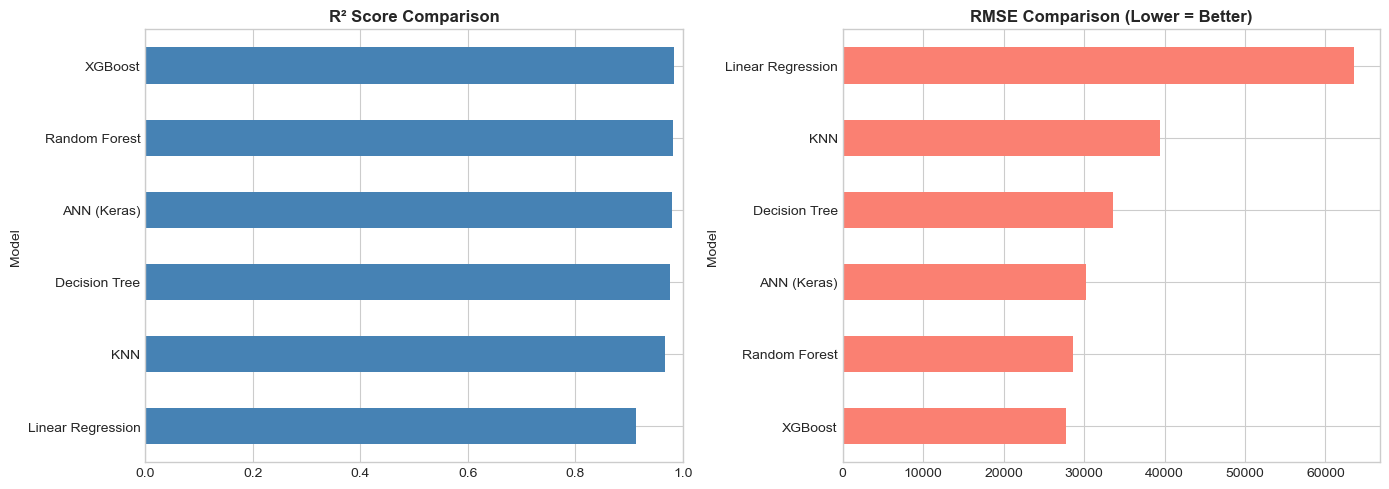

In [21]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df.sort_values('R2').plot(x='Model', y='R2', kind='barh', ax=axes[0],
                                  color='steelblue', legend=False)
axes[0].set_title('R² Score Comparison', fontweight='bold')
axes[0].set_xlim(0, 1)

results_df.sort_values('RMSE').plot(x='Model', y='RMSE', kind='barh', ax=axes[1],
                                    color='salmon', legend=False)
axes[1].set_title('RMSE Comparison (Lower = Better)', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Save best model (XGBoost typically wins)
best_model_row = results_df.sort_values('R2', ascending=False).iloc[0]
print(f'Best Model: {best_model_row["Model"]} | R²: {best_model_row["R2"]}')

# Save XGBoost as best (adjust if ANN is better)
with open('best_regression_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save ANN separately
ann.save('ann_model.keras')
print('✅ Models saved!')

Best Model: XGBoost | R²: 0.9834
✅ Models saved!


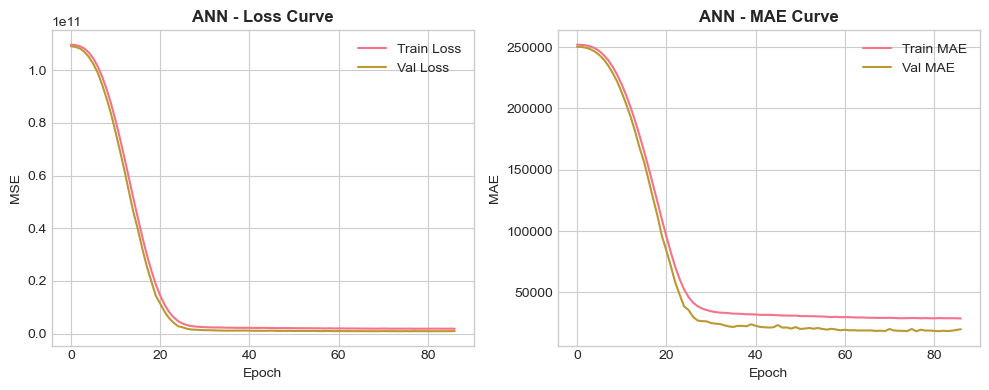

In [23]:
# ANN Training Loss Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN - Loss Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('ANN - MAE Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend()
plt.tight_layout()
plt.savefig('ann_training.png', dpi=150, bbox_inches='tight')
plt.show()

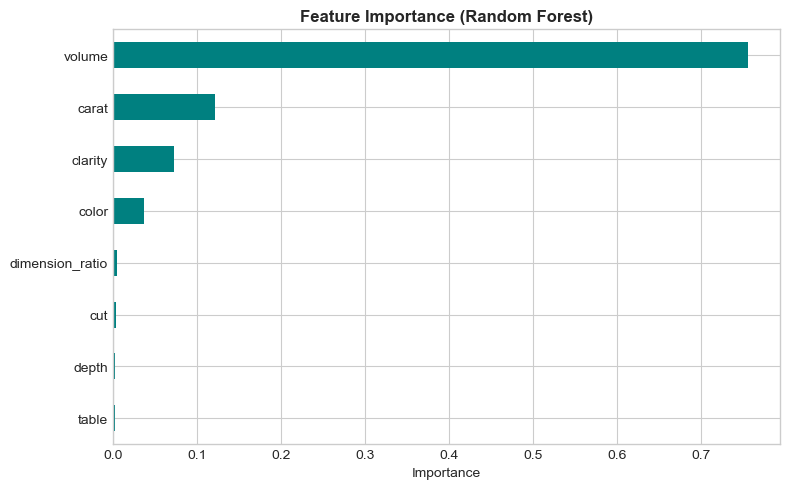

In [24]:
# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=features_final).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##  11. Clustering — Market Segmentation

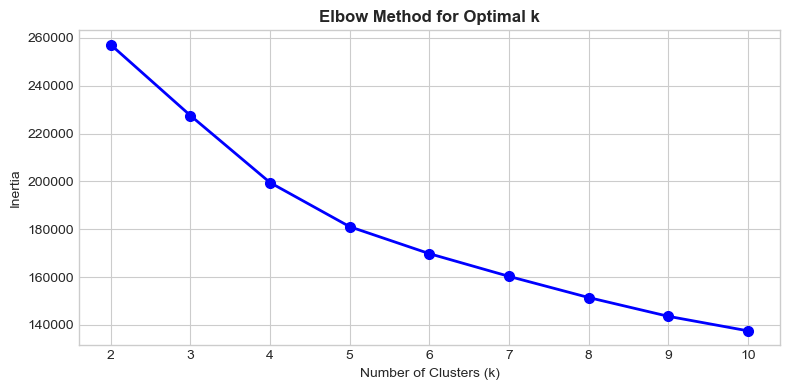

In [25]:
# Clustering features (exclude price)
cluster_features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'volume']
X_clust = df_encoded[cluster_features]

scaler_clust = StandardScaler()
X_clust_sc   = scaler_clust.fit_transform(X_clust)

with open('scaler_cluster.pkl', 'wb') as f:
    pickle.dump(scaler_clust, f)

# Elbow Method
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_sc)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k', fontweight='bold')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

Best k by Silhouette Score: 2 (0.2529)


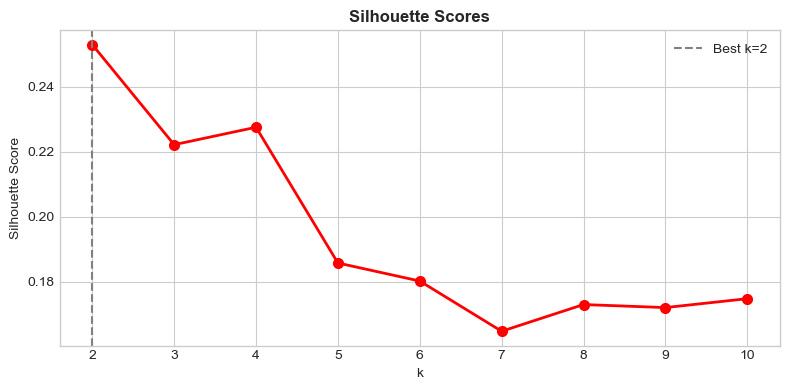

In [26]:
# Silhouette Score for k=2..10
sil_scores = []
for k in K_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_clust_sc)
    sil_scores.append(silhouette_score(X_clust_sc, labs))

best_k = K_range[np.argmax(sil_scores)]
print(f'Best k by Silhouette Score: {best_k} ({max(sil_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=7)
plt.axvline(best_k, linestyle='--', color='gray', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Final KMeans with best_k (we'll use 3 for interpretability)
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_encoded['cluster'] = kmeans.fit_predict(X_clust_sc)

# Analyze clusters
cluster_analysis = df_encoded.groupby('cluster').agg(
    avg_price   =('price', 'mean'),
    avg_carat   =('carat', 'mean'),
    avg_cut     =('cut',   'mean'),
    count       =('price', 'count')
).round(2)
print(cluster_analysis)

# Name the clusters based on analysis
# Sort by avg_price to assign labels
price_rank = cluster_analysis['avg_price'].rank()
cluster_names = {}
for idx, rank in price_rank.items():
    if rank == 1:   cluster_names[idx] = 'Affordable Small Diamonds'
    elif rank == 2: cluster_names[idx] = 'Mid-range Balanced Diamonds'
    else:           cluster_names[idx] = 'Premium Heavy Diamonds'

df_encoded['cluster_name'] = df_encoded['cluster'].map(cluster_names)
print('\nCluster Label Mapping:', cluster_names)

         avg_price  avg_carat  avg_cut  count
cluster                                      
0          5649.12       1.11     2.67  16819
1          1330.96       0.44     3.34  23755
2          2559.50       0.66     2.21   8939

Cluster Label Mapping: {0: 'Premium Heavy Diamonds', 1: 'Affordable Small Diamonds', 2: 'Mid-range Balanced Diamonds'}


In [28]:
# Save KMeans model and cluster names
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('cluster_names.pkl', 'wb') as f:
    pickle.dump(cluster_names, f)

print('✅ Clustering models saved!')

✅ Clustering models saved!


##  12. Dimensionality Reduction with PCA

Explained Variance Ratio: [0.35199095 0.19363988]
Total Variance Explained: 0.5456


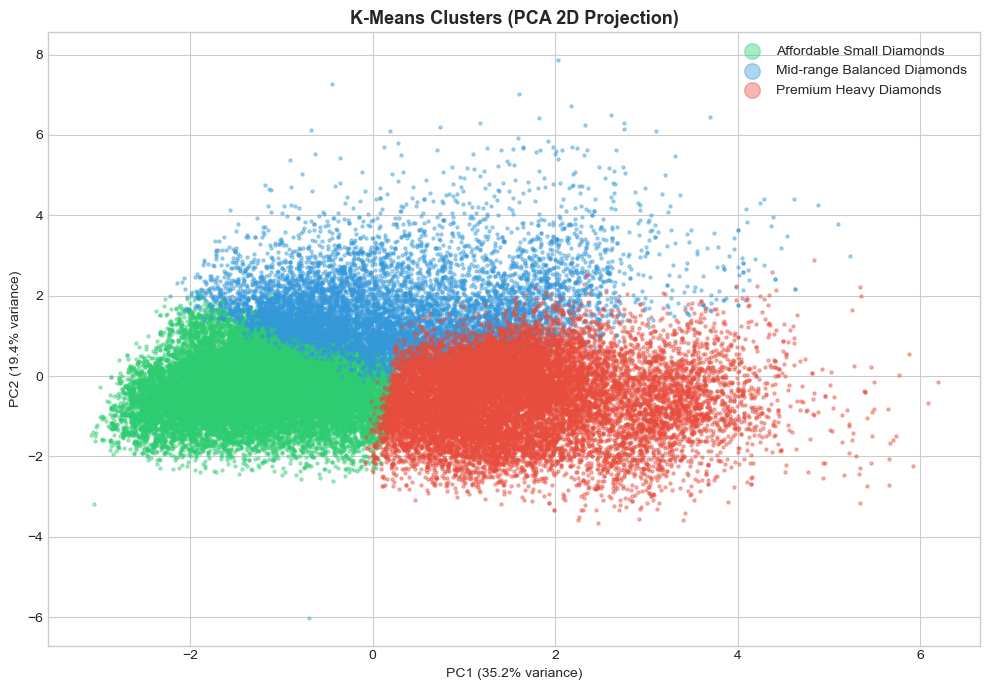

In [29]:
# PCA to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_sc)

print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')
print(f'Total Variance Explained: {pca.explained_variance_ratio_.sum():.4f}')

# 2D PCA Cluster Plot
palette = {'Affordable Small Diamonds': '#2ecc71',
           'Mid-range Balanced Diamonds': '#3498db',
           'Premium Heavy Diamonds': '#e74c3c'}

plt.figure(figsize=(10, 7))
for name, color in palette.items():
    mask = df_encoded['cluster_name'] == name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=name, alpha=0.4, s=5, color=color)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (PCA 2D Projection)', fontsize=13, fontweight='bold')
plt.legend(markerscale=5)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

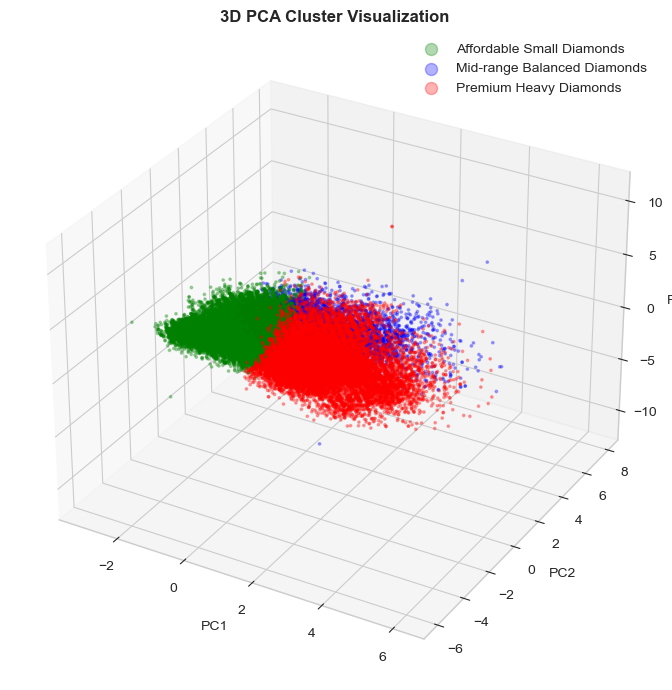

In [30]:
# 3D PCA Plot
pca3d = PCA(n_components=3, random_state=42)
X_pca3 = pca3d.fit_transform(X_clust_sc)

color_map  = {'Affordable Small Diamonds': 'green',
               'Mid-range Balanced Diamonds': 'blue',
               'Premium Heavy Diamonds': 'red'}

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

for name, color in color_map.items():
    mask = df_encoded['cluster_name'] == name
    ax.scatter(X_pca3[mask,0], X_pca3[mask,1], X_pca3[mask,2],
               label=name, alpha=0.3, s=3, c=color)

ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('3D PCA Cluster Visualization', fontweight='bold')
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig('pca_3d_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

=== Final Cluster Summary ===
               cluster_name  Count Avg_Price_INR  Avg_Carat
  Affordable Small Diamonds  23755      ₹111,135      0.440
Mid-range Balanced Diamonds   8939      ₹213,718      0.663
     Premium Heavy Diamonds  16819      ₹471,701      1.107


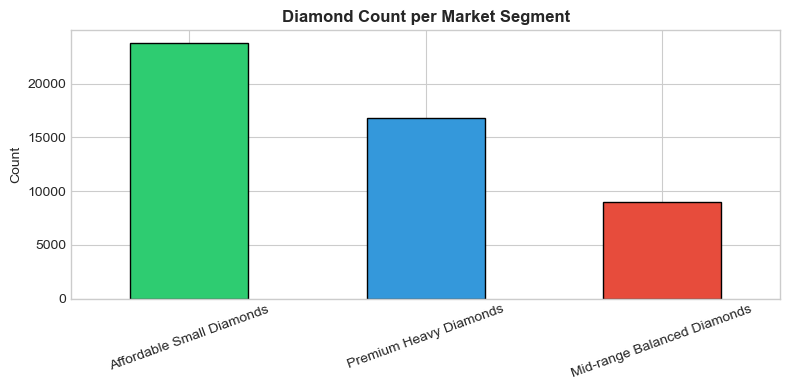

In [31]:
# Cluster Distribution Summary
print('=== Final Cluster Summary ===')
summary = df_encoded.groupby('cluster_name').agg(
    Count      =('price', 'count'),
    Avg_Price_INR=('price_inr', lambda x: f'₹{x.mean():,.0f}'),
    Avg_Carat  =('carat', lambda x: round(x.mean(), 3)),
).reset_index()
print(summary.to_string(index=False))

# Cluster count bar chart
plt.figure(figsize=(8, 4))
counts = df_encoded['cluster_name'].value_counts()
counts.plot(kind='bar', color=['#2ecc71','#3498db','#e74c3c'], edgecolor='black')
plt.title('Diamond Count per Market Segment', fontweight='bold')
plt.ylabel('Count'); plt.xlabel('')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##  13. Save Final Feature Info for Streamlit

In [ ]:
import json

# Save feature list and metadata
model_meta = {
    'features_final':   features_final,
    'cluster_features': cluster_features,
    'USD_TO_INR':       USD_TO_INR,
    'cut_order':        cut_order,
    'color_order':      color_order,
    'clarity_order':    clarity_order,
    'cluster_names':    cluster_names
}
with open('model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('✅ All artifacts saved:')
print('  - best_regression_model.pkl (XGBoost)')
print('  - ann_model.keras')
print('  - kmeans_model.pkl')
print('  - scaler.pkl')
print('  - scaler_cluster.pkl')
print('  - ordinal_encoder.pkl')
print('  - cluster_names.pkl')
print('  - model_meta.json')

✅ All artifacts saved:
  - best_regression_model.pkl (XGBoost)
  - ann_model.keras
  - kmeans_model.pkl
  - scaler.pkl
  - scaler_cluster.pkl
  - ordinal_encoder.pkl
  - cluster_names.pkl
  - model_meta.json
